### Evaluation Results Visualization

This notebook analyzes and visualizes evaluation results from session data.
It provides:
- Summary statistics (Passed/Failed sessions)
- Found vs Not Found analysis
- Chunk ID distribution
- Failure reason analysis using AI

#### 1. Setup and Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from helper import read_system_instructions
from openai import OpenAI

# Configure matplotlib for better visualization
plt.style.use('default')
%matplotlib inline

#### 2. Configuration

In [45]:
# Update these paths according to your setup
RESULTS_CSV_PATH = 'aax_results/aax_results-5-gepa.csv'
EXTRACT_REASON_INSTRUCTIONS_PATH = 'src/system_instructions/extract_top_reason_instructions.md'
SESSION_FAILURE_ANALYSIS_PATH = 'session_level_failure_analysis_instructions.md'

os.environ["OPENAI_API_KEY"] = "YOUR-API-KEY"  # Replace with your OpenAI API key

# Initialize OpenAI client
client = OpenAI()

#### 3. Load Data

In [46]:
# Load the results dataframe
result_df = pd.read_csv(RESULTS_CSV_PATH)

# Display basic information about the dataset
print(f"Dataset shape: {result_df.shape}")
print(f"\nColumns: {result_df.columns.tolist()}")
print(f"\nFirst few rows:")
result_df.head()

Dataset shape: (53, 11)

Columns: ['Session ID', 'Turn', 'Question', 'Expected Chunk ID', 'Actual Chunk ID', 'Expected Answer', 'Found', 'Actual Answer', 'Result', 'Comments', 'Reasons for Failure']

First few rows:


,Session ID,Turn,Question,Expected Chunk ID,Actual Chunk ID,Expected Answer,Found,Actual Answer,Result,Comments,Reasons for Failure
0,1,1,สอบถามหน่อยครับ ต้นเดือนหน้าผมจะเริ่มว่างงาน ถ...,13,"13,1,17,27,28,44,37,45,36,43,8,40",ได้เลยครับ เบื้องต้นผมของสอบถามข้อมูลเพิ่มเติม...,True,สวัสดีค่ะ ดิฉันน้องออมสุข จากสำนักงานประกันสัง...,True,Retrieval is acceptable since it includes the ...,NaN
1,1,2,1. ใช่ครับ\n2.ลาออกเองครับ,13,"20,15,13,21,1,16,17,4,0,24,37,5",หากคุณเป็นผู้ประกันตนที่ส่งเงินสมทบครบ 6 เดือน...,True,สวัสดีค่ะ ดิฉันน้องออมสุข จากสำนักงานประกันสัง...,True,Retrieval is acceptable as it includes the exp...,NaN
2,2,1,ถ้าต้องการยื่นขึ้นทะเบียนประกันสังคมต้องใช้เอก...,1,"17,1,0,24,44,25,21,23,46,20,49,15",หลักฐานประจำตัวผู้ประกันตน มีดังนี้\n1. สำหรับ...,True,สวัสดีค่ะ ดิฉันน้องออมสุข จากสำนักงานประกันสัง...,False,Retrieval is acceptable (includes the expected...,"[\n ""Answer off-topic or misaligned with the ..."
3,2,2,แล้วต้องไปยื่นขึ้นทะเบียนที่ไหน,1,"23,1,0,49,44,14,19,25,17,24,21,46",- กรณีนายจ้าง ที่มีสำนักงานใหญ่ตั้งอยู่ในเขตกร...,True,นายจ้างที่มีสำนักงานใหญ่ตั้งอยู่ในเขตกรุงเทพมห...,True,Answer matches the expected content accurately...,NaN
4,2,3,ต้องไปยื่นภายในกี่วัน,1,"44,49,21,13,16,17,1,6,46,20,28,7",เมื่อมีการรับลูกจ้างใหม่เพิ่มขึ้นต้องแจ้งขึ้นท...,True,นายจ้างต้องขึ้นทะเบียนนายจ้างพร้อมกับขึ้นทะเบี...,True,Retrieval is acceptable as it includes the exp...,NaN


#### 4. Summary Statistics

In [ ]:
print("=" * 40)
print("Evaluation Results Summary")
print("=" * 40)

total_sessions = result_df['Session ID'].nunique()
passed_sessions = result_df[result_df['Result'] == True]['Session ID'].nunique()
failed_sessions = total_sessions - passed_sessions

print(f"Total Sessions Evaluated: {total_sessions}")
print(f"Passed Sessions: {passed_sessions}")
print(f"Failed Sessions: {failed_sessions}")

#### 5. Visualization: Passed vs Failed Sessions

In [ ]:
labels = ['Passed', 'Failed']
sizes = [passed_sessions, failed_sessions]
colors = ['#4CAF50', '#FF5733']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, sizes, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{int(height)} ({height / sum(sizes) * 100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Evaluation Results Summary', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Sessions', fontsize=12, fontweight='bold')
plt.ylim(0, max(sizes) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Bar chart displayed successfully.")

Visualization: Passed vs Failed Turns

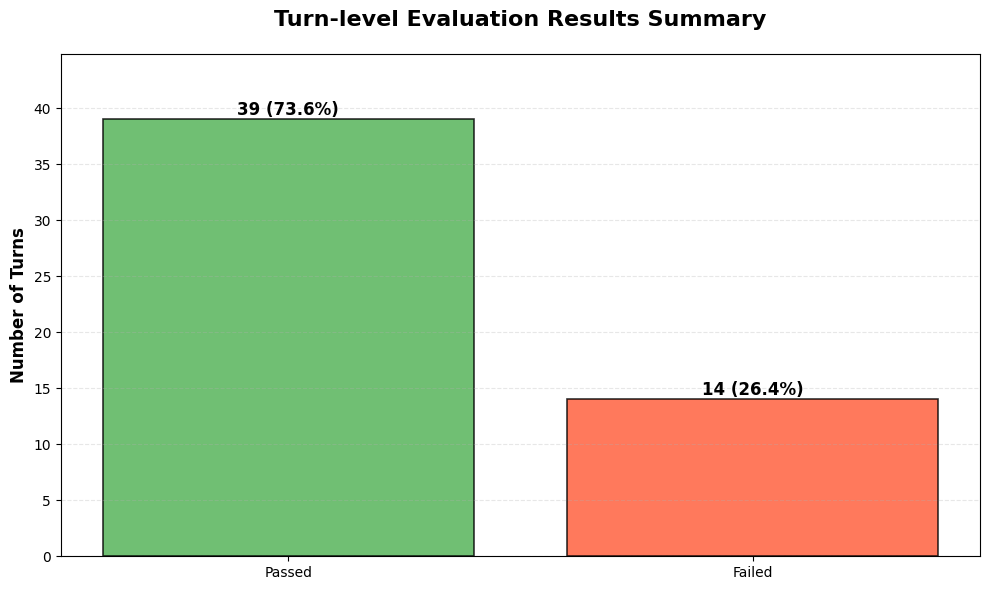

In [47]:
labels = ['Passed', 'Failed']
passed_turns = len(result_df[result_df['Result'] == True])
failed_turns = len(result_df) - passed_turns
sizes = [passed_turns, failed_turns]
colors = ['#4CAF50', '#FF5733']
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, sizes, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{int(height)} ({height / sum(sizes) * 100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Turn-level Evaluation Results Summary', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Turns', fontsize=12, fontweight='bold')
plt.ylim(0, max(sizes) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### 6. Visualization: Found vs Not Found

In [48]:
if 'Found' not in result_df.columns:
    result_df.insert(6, 'Found', '')
for index, row in result_df.iterrows():
    if pd.isna(row['Actual Chunk ID']):
        result_df.at[index, 'Found'] = False
        continue
    elif pd.isna(row['Expected Chunk ID']):
        result_df.at[index, 'Found'] = True
        continue
    expected = set(map(int, str(row['Expected Chunk ID']).split(',')))
    actual = set(map(int, str(row['Actual Chunk ID']).split(',')))
    if expected.issubset(actual):
        result_df.at[index, 'Found'] = True
    else:
        result_df.at[index, 'Found'] = False

Found vs Not Found Analysis


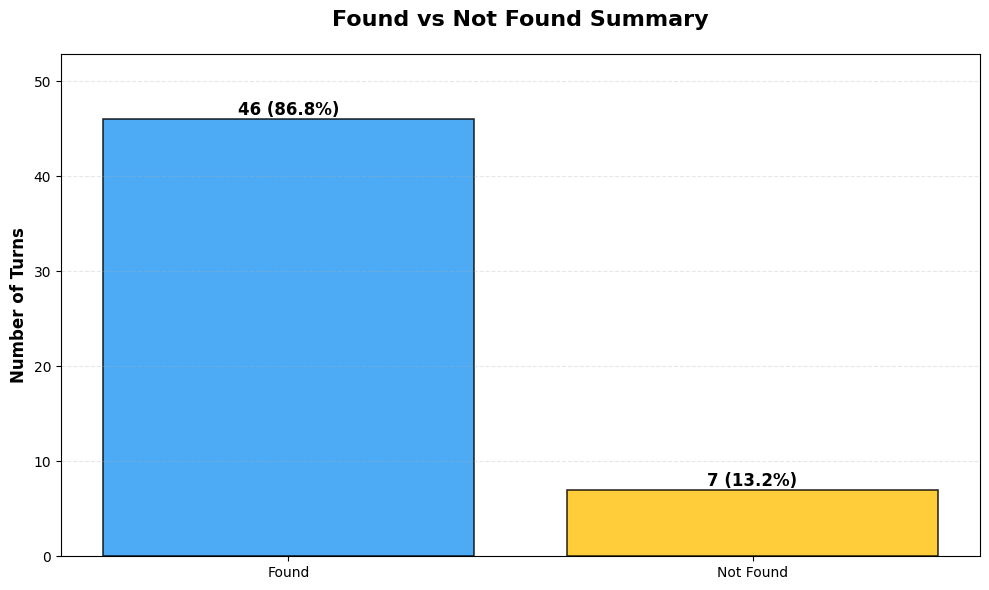

Found vs Not Found bar chart displayed successfully.


In [49]:
print("=" * 40)
print("Found vs Not Found Analysis")
print("=" * 40)

found_counts = result_df['Found'].value_counts()
labels = ['Found', 'Not Found']
sizes = [found_counts.get(True, 0), found_counts.get(False, 0)]
colors = ['#2196F3', '#FFC107']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, sizes, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{int(height)} ({height / sum(sizes) * 100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Found vs Not Found Summary', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Turns', fontsize=12, fontweight='bold')
plt.ylim(0, max(sizes) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Found vs Not Found bar chart displayed successfully.")

#### 7. Visualization: Chunk ID Distribution

In [ ]:
print("=" * 40)
print("Chunk ID Distribution")
print("=" * 40)

all_chunk_ids_expect = result_df['Expected Chunk ID'].dropna().str.split(',').explode()
chunk_id_distribution_expect = all_chunk_ids_expect.value_counts().sort_index()
all_chunk_ids_actual = result_df['Actual Chunk ID'].dropna().str.split(',').explode()
chunk_id_distribution_actual = all_chunk_ids_actual.value_counts().sort_index()

plt.figure(figsize=(10, 6))
# Compare expected vs actual chunk ID distributions
width = 0.35
x = range(len(chunk_id_distribution_expect))
bars1 = plt.bar([i - width/2 for i in x], chunk_id_distribution_expect.values, width=width,
                 color='#8E44AD', label='Expected', edgecolor='black', linewidth=1.2, alpha=0.8)
bars2 = plt.bar([i + width/2 for i in x], chunk_id_distribution_actual.reindex(chunk_id_distribution_expect.index, fill_value=0).values,
                 width=width, color='#27AE60', label='Actual', edgecolor='black', linewidth=1.2, alpha=0.8)
plt.xticks(x, chunk_id_distribution_expect.index.astype(int))
plt.xlabel('Chunk ID', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Chunk ID Distribution (Expected vs Actual)', fontsize=16, fontweight='bold', pad=20)
# Add comments to the plot
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


print("Chunk ID distribution chart displayed successfully.")

#### 8. Extract Top Failure Reasons Using AI

In [ ]:
print("=" * 40)
print("Extracting Top Reasons for Failure")
print("=" * 40)

# Collect unique comments
unique_comments = result_df['Comments'].unique()
comments = "List of Unique Comments from Evaluations:\n"
for comment in unique_comments:
    comments += f"- {comment}\n"

# Load instructions
with open(EXTRACT_REASON_INSTRUCTIONS_PATH, 'r') as f:
    extract_reason_instruction = f.read()

# Call AI to extract top reasons
print("Analyzing comments with AI...")
response = client.responses.create(
    model='gpt-5',
    instructions=extract_reason_instruction,
    input=comments
)
top_reasons = response.output_text

print(f"Top reasons extracted:\n{top_reasons}")

#### 9. Analyze Each Failed Turn

In [ ]:
print("=" * 40)
print("Analyzing Reasons for Failure in Each Turn")
print("=" * 40)

result_df['Reasons for Failure'] = ''

sessions = result_df.groupby('Session ID')
for session_id, session_df in sessions:
    print("=" * 20)
    print(f"Analyzing Session ID: {session_id}")
    for idx, row in session_df.iterrows():
        if row['Result'] == True:
            continue  # Skip passed turns
        else:
            print(f"Analyzing Turn: {row['Turn']}")
            # Prepare input for AI, Split each reason on a new line for clarity
            input_text = f"Turn: {row['Turn']}\n"
            input_text += f"Comments: {row['Comments']}\n"

            response = client.responses.create(
                model='gpt-5',
                instructions=read_system_instructions(SESSION_FAILURE_ANALYSIS_PATH).replace("{top_reasons}", json.dumps(top_reasons, ensure_ascii=False)),
                input=input_text
            )
            reasons = response.output_text
            result_df.at[idx, 'Reasons for Failure'] = reasons
print("Completed analysis of failure reasons for all failed turns.")


#### 10. Visualization: Failure Reasons Distribution

Failure Reasons Distribution


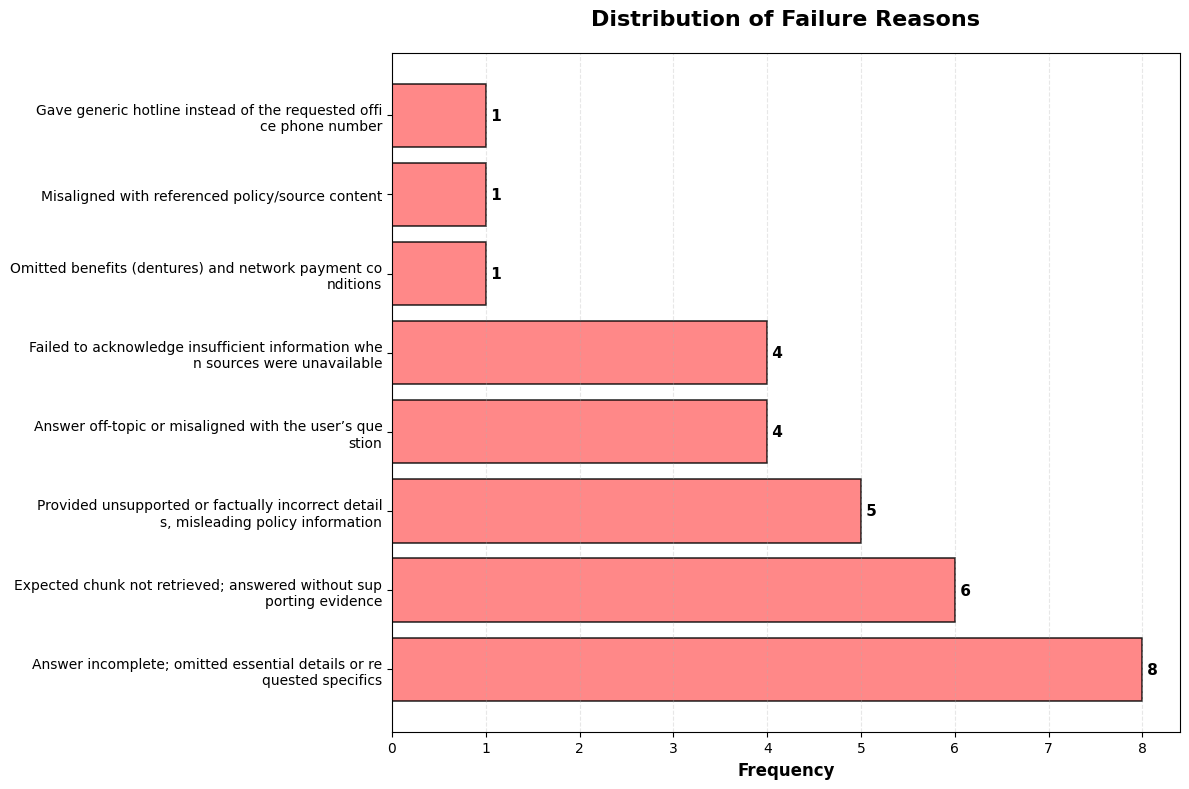

Failure reasons distribution chart displayed successfully.


In [50]:
print("=" * 40)
print("Failure Reasons Distribution")
print("=" * 40)

# Filter out empty strings and only keep non-empty failure reasons
failure_reasons = result_df['Reasons for Failure'].dropna()
failure_reasons = failure_reasons[failure_reasons != '']

# Parse JSON strings safely
def parse_reasons(reason_str):
    try:
        return json.loads(reason_str)
    except (json.JSONDecodeError, TypeError):
        return []

all_reasons = failure_reasons.apply(parse_reasons).explode()
# Remove any None or empty values
all_reasons = all_reasons[all_reasons.notna()]
reason_counts = all_reasons.value_counts()

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(reason_counts)), reason_counts.values,
                color='#FF6B6B', edgecolor='black', linewidth=1.2, alpha=0.8)

# Wrap long labels for better readability
wrapped_labels = ['\n'.join([reason[i:i + 50] for i in range(0, len(reason), 50)])
                  for reason in reason_counts.index]
plt.yticks(range(len(reason_counts)), wrapped_labels, fontsize=10)

# Add count labels
for i, (bar, count) in enumerate(zip(bars, reason_counts.values)):
    plt.text(count, i, f' {count}',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.xlabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Failure Reasons', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Failure reasons distribution chart displayed successfully.")

#### 11. Save Results

In [ ]:
print("=" * 40)
print("Saving Results")
print("=" * 40)

result_df.to_csv(RESULTS_CSV_PATH, index=False, encoding='utf-8')
print(f"Results with reasons for failure saved to: {RESULTS_CSV_PATH}")

# Display final dataframe info
print(f"\nFinal dataset shape: {result_df.shape}")
print("\nColumns in final dataset:")
print(result_df.columns.tolist())